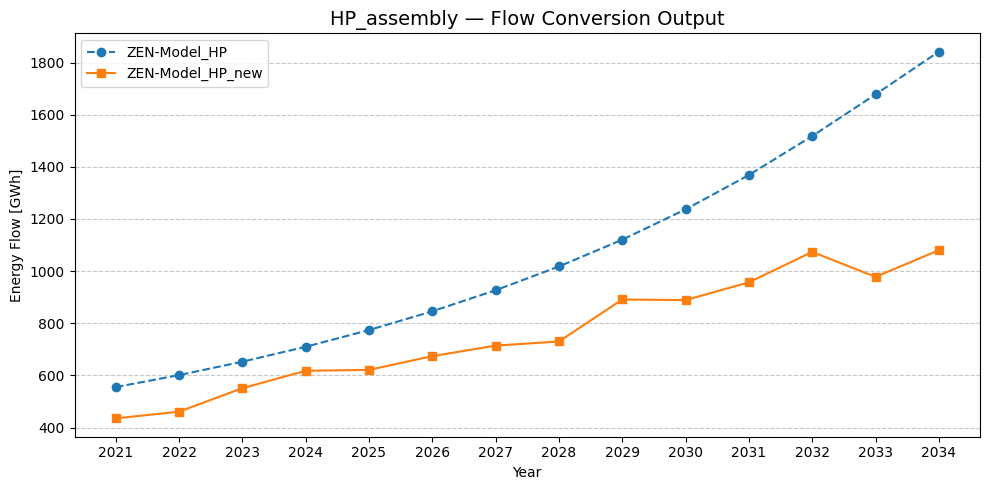

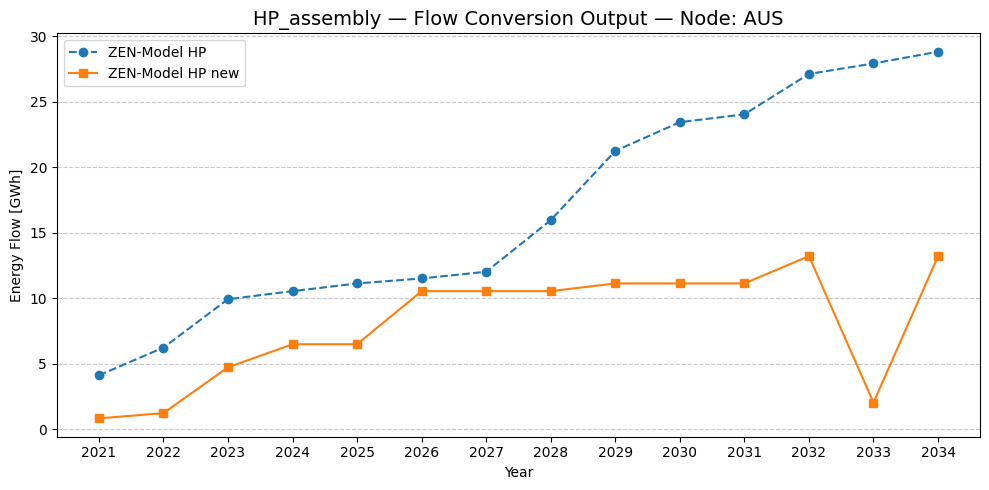

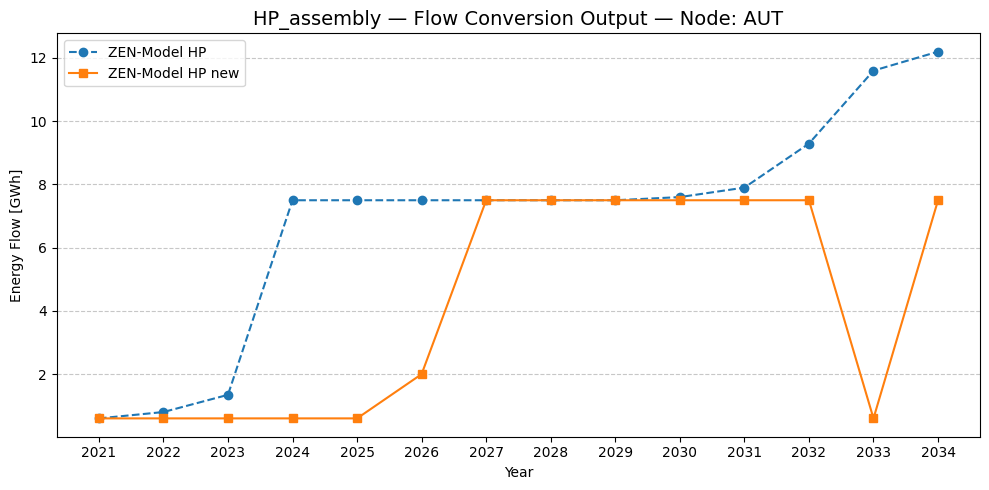

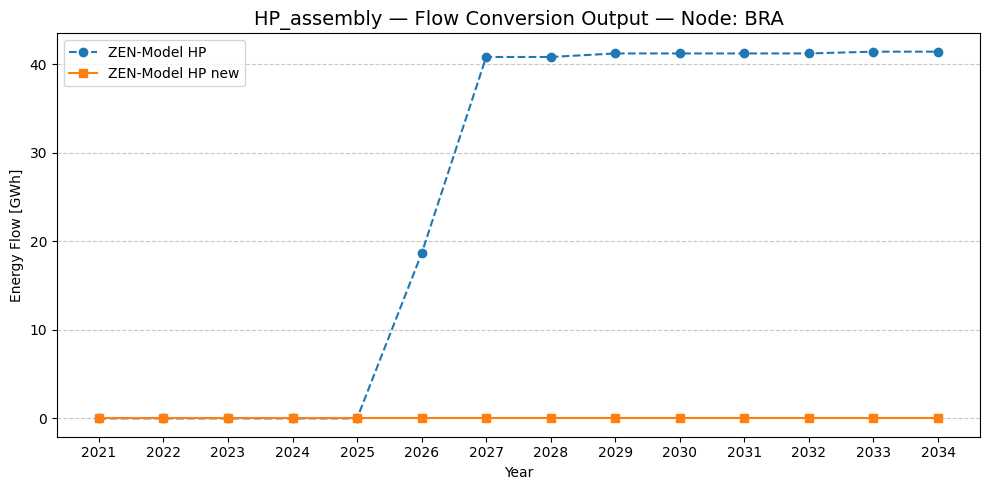

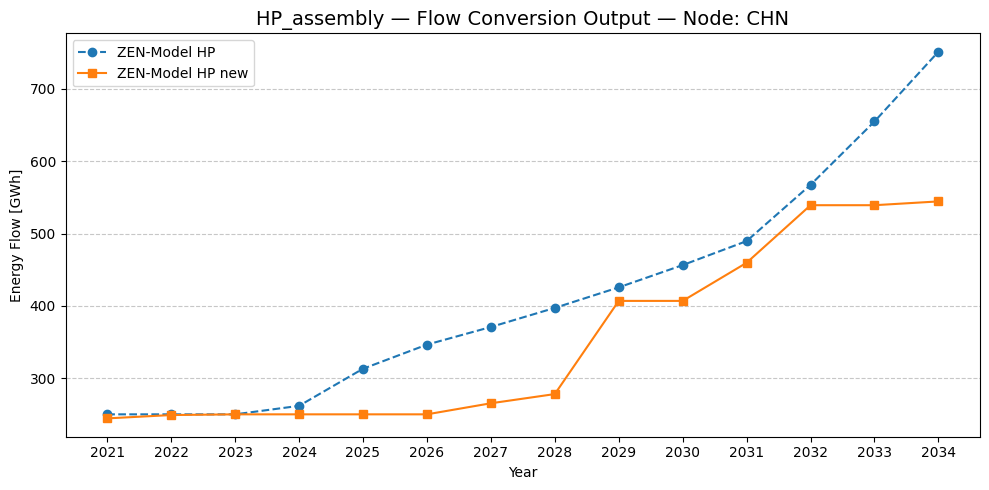

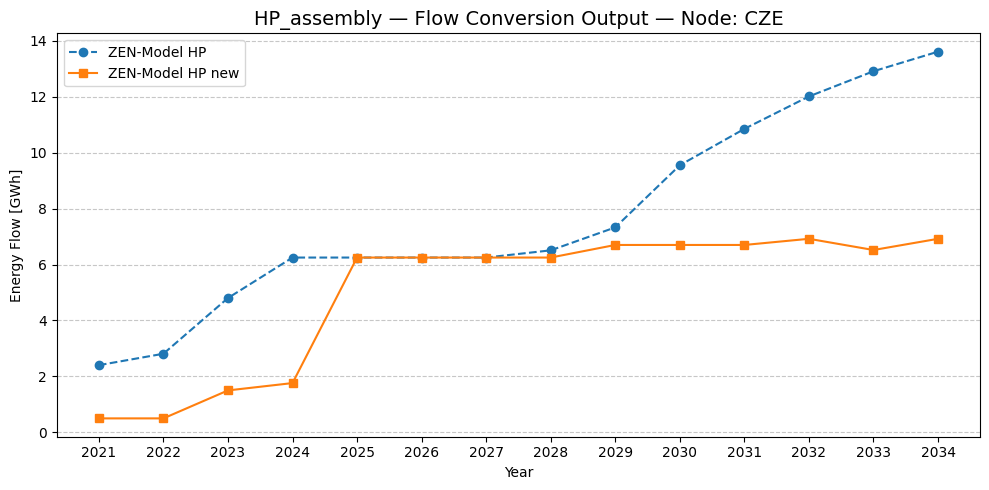

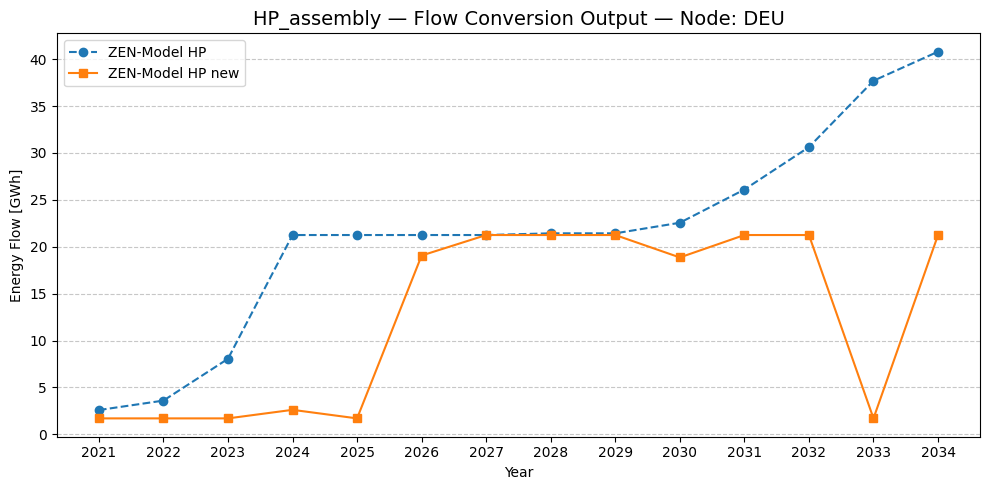

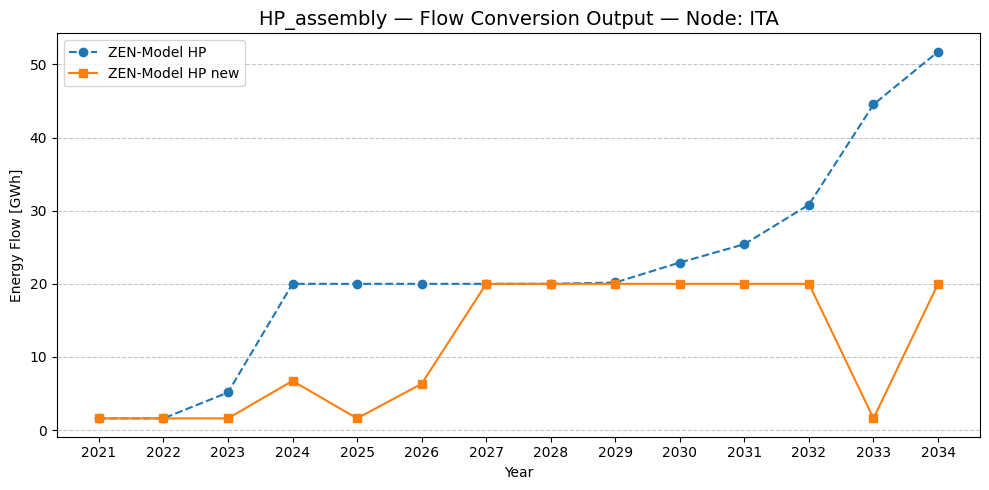

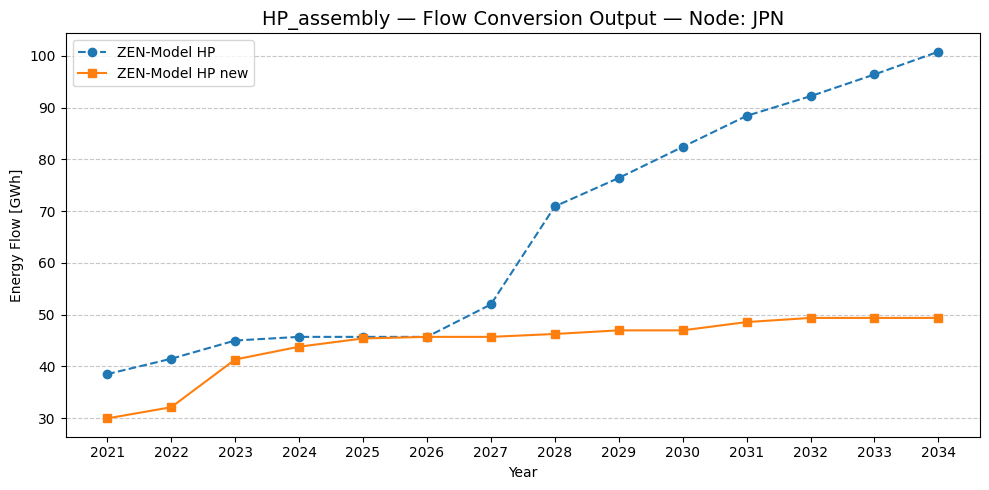

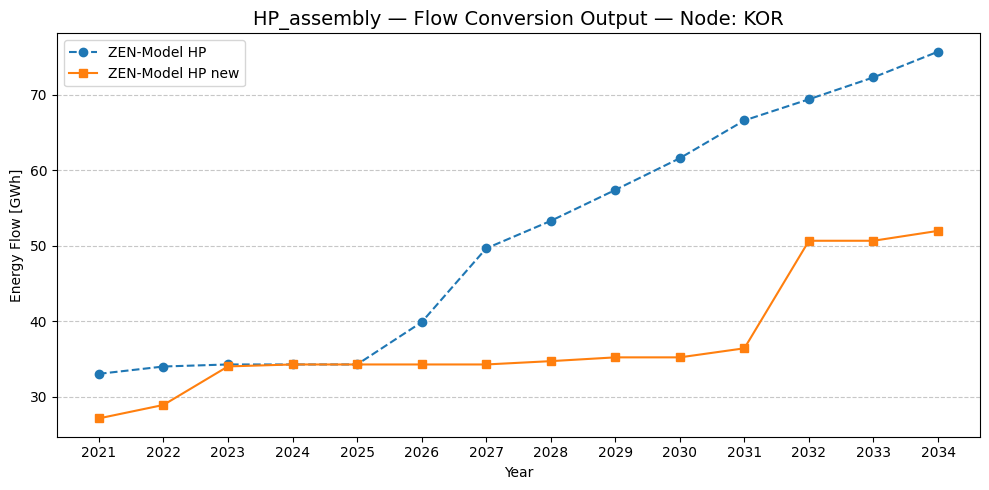

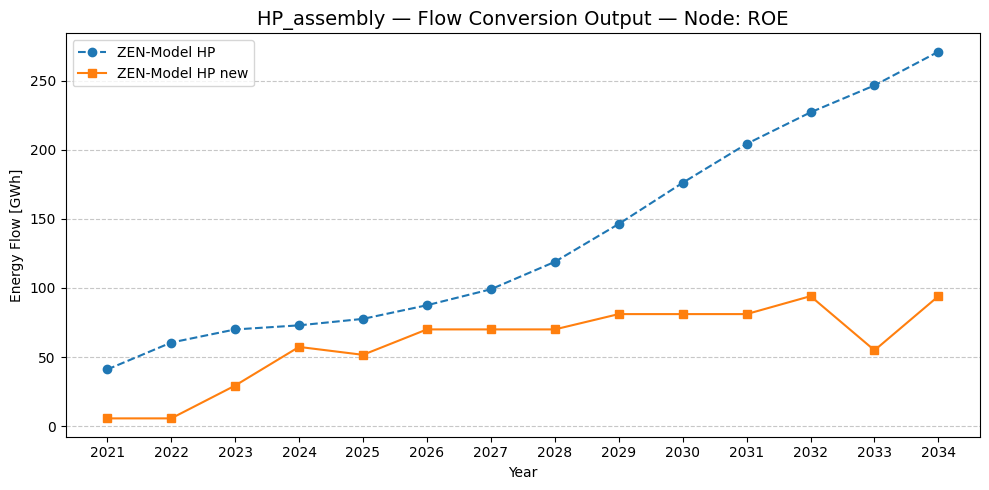

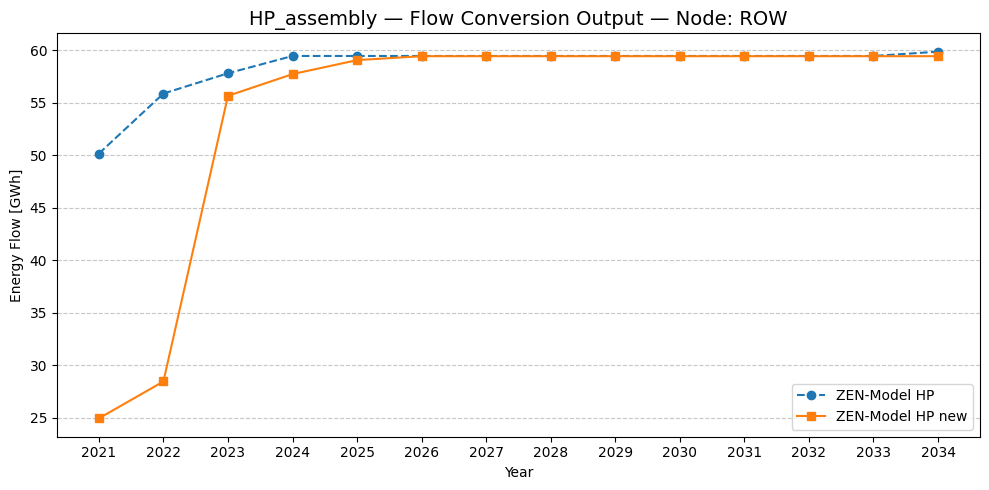

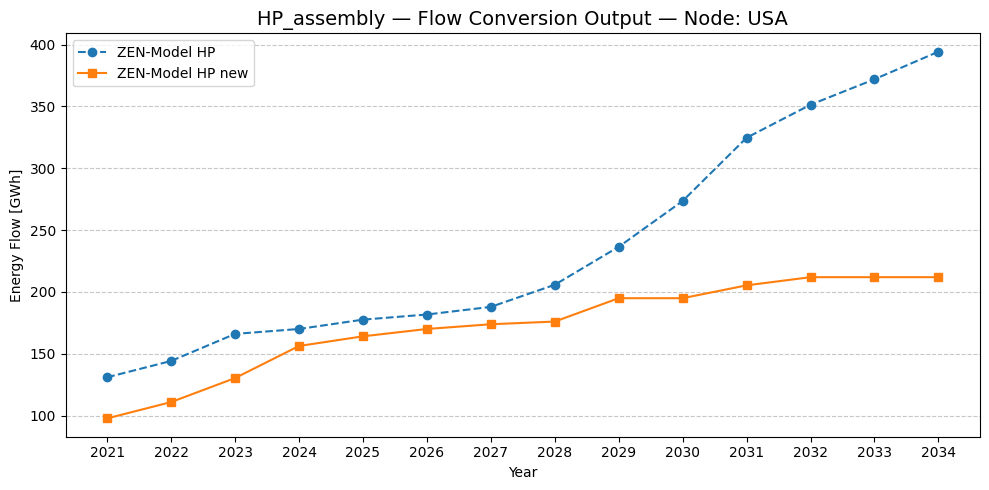

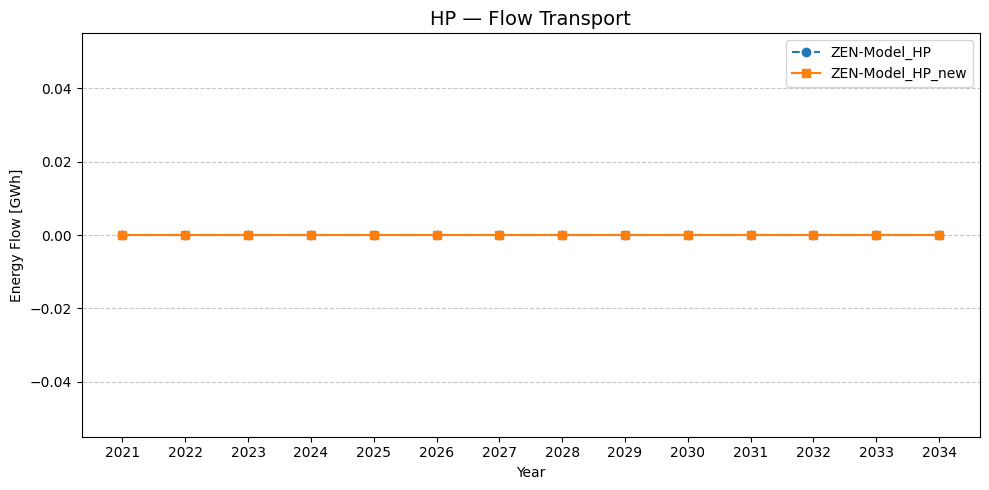

⚠️ No valid grouping column (node/origin) in flow_import


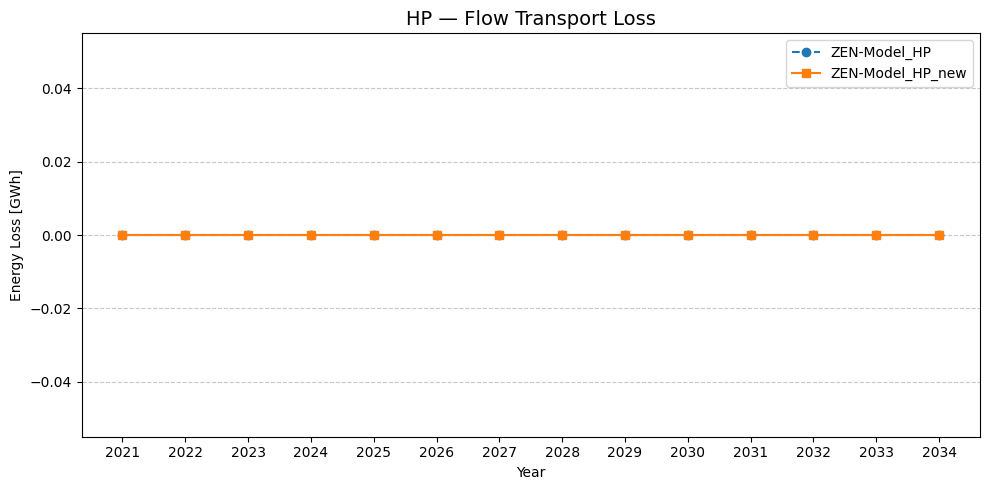

In [8]:
import os
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from zen_garden.postprocess.results import Results

# === Dataset Setup ===
dataset_name_1 = 'ZEN-Model_HP'
dataset_name_2 = 'ZEN-Model_HP_new'
technology_filter = "HP_assembly"
carrier_filter = "HP"

r1 = Results(os.path.join("outputs", dataset_name_1))
r2 = Results(os.path.join("outputs", dataset_name_2))

# === Save Paths ===
save_plots = False
save_path = Path(
    r"C:\Users\nicol\OneDrive\Desktop\Semester_project\Plots_and_Figures\SCM_plots\conversion_flow_comparison")
csv_export_path = Path(r"C:\Users\nicol\OneDrive\Desktop\Semester_project\Plots_and_Figures\device_demand_data")
os.makedirs(save_path, exist_ok=True)
os.makedirs(csv_export_path, exist_ok=True)

# === Style Settings ===
start_year = 2021
marker_styles = {dataset_name_1: 'o', dataset_name_2: 's'}
colors = {dataset_name_1: '#1f77b4', dataset_name_2: '#ff7f0e'}
linestyles = {dataset_name_1: '--', dataset_name_2: '-'}
line_widths = {dataset_name_1: 1.5, dataset_name_2: 1.5}


# === Plot: Flow Conversion Output (tech-specific) ===
def plot_conversion_output_total_and_by_node():
    var_name = "flow_conversion_output"
    df1 = r1.get_full_ts(var_name).reset_index()
    df2 = r2.get_full_ts(var_name).reset_index()
    df1 = df1[df1["technology"] == technology_filter]
    df2 = df2[df2["technology"] == technology_filter]

    time_cols = [col for col in df1.columns if isinstance(col, (int, float))]

    # Total plot
    total1 = df1[time_cols].sum()
    total2 = df2[time_cols].sum()
    plt.figure(figsize=(10, 5))
    plt.plot(time_cols, total1, label=dataset_name_1, color=colors[dataset_name_1],
             linestyle=linestyles[dataset_name_1], marker=marker_styles[dataset_name_1])
    plt.plot(time_cols, total2, label=dataset_name_2, color=colors[dataset_name_2],
             linestyle=linestyles[dataset_name_2], marker=marker_styles[dataset_name_2])
    plt.title(f"{technology_filter} — Flow Conversion Output", fontsize=14)
    plt.xlabel("Year")
    plt.ylabel("Energy Flow [GWh]")
    plt.grid(axis='y', linestyle="--", alpha=0.7)
    plt.legend()
    plt.tight_layout()
    plt.xticks(ticks=time_cols, labels=[str(start_year + i) for i in range(len(time_cols))])
    if save_plots:
        plt.savefig(save_path / f"{var_name}_{technology_filter}_total.pdf", format='pdf', bbox_inches='tight')
    plt.show()

    # By node
    df1_grouped = df1.groupby("node")[time_cols].sum()
    df2_grouped = df2.groupby("node")[time_cols].sum()
    for node in sorted(set(df1_grouped.index).union(df2_grouped.index)):
        if df1_grouped.loc[node].sum() == 0 and df2_grouped.loc[node].sum() == 0:
            continue
        plt.figure(figsize=(10, 5))
        for label, grouped in zip([dataset_name_1, dataset_name_2], [df1_grouped, df2_grouped]):
            if node in grouped.index:
                plt.plot(time_cols, grouped.loc[node], label=label.replace("_", " "),
                         color=colors[label], linestyle=linestyles[label],
                         marker=marker_styles[label], linewidth=line_widths[label])
        plt.title(f"{technology_filter} — Flow Conversion Output — Node: {node}", fontsize=14)
        plt.xlabel("Year")
        plt.ylabel("Energy Flow [GWh]")
        plt.grid(axis='y', linestyle='--', alpha=0.7)
        plt.legend()
        plt.tight_layout()
        plt.xticks(ticks=time_cols, labels=[str(start_year + i) for i in range(len(time_cols))])
        if save_plots:
            plt.savefig(save_path / f"{var_name}_{technology_filter}_{node}.pdf", format='pdf', bbox_inches='tight')
        plt.show()


# === Plot: Flow Transport (carrier-based, by node) ===
def plot_carrier_transport():
    var_name = "flow_transport"
    df1 = r1.get_full_ts(var_name).reset_index()
    df2 = r2.get_full_ts(var_name).reset_index()

    # Filter if 'carrier' column exists
    if "carrier" in df1.columns:
        df1 = df1[df1["carrier"] == carrier_filter]
    if "carrier" in df2.columns:
        df2 = df2[df2["carrier"] == carrier_filter]

    time_cols = [col for col in df1.columns if isinstance(col, (int, float))]

    # Total
    total1 = df1[time_cols].sum()
    total2 = df2[time_cols].sum()

    plt.figure(figsize=(10, 5))
    plt.plot(time_cols, total1, label=dataset_name_1, color=colors[dataset_name_1],
             linestyle=linestyles[dataset_name_1], marker=marker_styles[dataset_name_1])
    plt.plot(time_cols, total2, label=dataset_name_2, color=colors[dataset_name_2],
             linestyle=linestyles[dataset_name_2], marker=marker_styles[dataset_name_2])
    plt.title(f"{carrier_filter} — Flow Transport", fontsize=14)
    plt.xlabel("Year")
    plt.ylabel("Energy Flow [GWh]")
    plt.grid(axis='y', linestyle="--", alpha=0.7)
    plt.legend()
    plt.tight_layout()
    plt.xticks(ticks=time_cols, labels=[str(start_year + i) for i in range(len(time_cols))])
    if save_plots:
        plt.savefig(save_path / f"{var_name}_{carrier_filter}_total.pdf", format='pdf', bbox_inches='tight')
    plt.show()

    # By node (using origin or destination if available)
    group_column = "edge" if "edge" in df1.columns else "origin" if "origin" in df1.columns else None
    if not group_column:
        print(f"⚠️ No valid grouping column (node/origin) in {var_name}")
        return

    df1_grouped = df1.groupby(group_column)[time_cols].sum()
    df2_grouped = df2.groupby(group_column)[time_cols].sum()

    for node in sorted(set(df1_grouped.index).union(df2_grouped.index)):
        if df1_grouped.loc[node].sum() == 0 and df2_grouped.loc[node].sum() == 0:
            continue
        plt.figure(figsize=(10, 5))
        for label, grouped in zip([dataset_name_1, dataset_name_2], [df1_grouped, df2_grouped]):
            if node in grouped.index:
                plt.plot(time_cols, grouped.loc[node], label=label.replace("_", " "),
                         color=colors[label], linestyle=linestyles[label],
                         marker=marker_styles[label], linewidth=line_widths[label])
        plt.title(f"{carrier_filter} — Flow Transport — {group_column.title()}: {node}", fontsize=14)
        plt.xlabel("Year")
        plt.ylabel("Energy Flow [GWh]")
        plt.grid(axis='y', linestyle='--', alpha=0.7)
        plt.legend()
        plt.tight_layout()
        plt.xticks(ticks=time_cols, labels=[str(start_year + i) for i in range(len(time_cols))])
        if save_plots:
            plt.savefig(save_path / f"{var_name}_{carrier_filter}_{node}.pdf", format='pdf', bbox_inches='tight')
        plt.show()


def plot_carrier_transport_loss():
    var_name = "flow_transport_loss"
    df1 = r1.get_full_ts(var_name).reset_index()
    df2 = r2.get_full_ts(var_name).reset_index()

    if "carrier" in df1.columns:
        df1 = df1[df1["carrier"] == carrier_filter]
    if "carrier" in df2.columns:
        df2 = df2[df2["carrier"] == carrier_filter]

    time_cols = [col for col in df1.columns if isinstance(col, (int, float))]

    total1 = df1[time_cols].sum()
    total2 = df2[time_cols].sum()

    plt.figure(figsize=(10, 5))
    plt.plot(time_cols, total1, label=dataset_name_1, color=colors[dataset_name_1],
             linestyle=linestyles[dataset_name_1], marker=marker_styles[dataset_name_1])
    plt.plot(time_cols, total2, label=dataset_name_2, color=colors[dataset_name_2],
             linestyle=linestyles[dataset_name_2], marker=marker_styles[dataset_name_2])
    plt.title(f"{carrier_filter} — Flow Transport Loss", fontsize=14)
    plt.xlabel("Year")
    plt.ylabel("Energy Loss [GWh]")
    plt.grid(axis='y', linestyle="--", alpha=0.7)
    plt.legend()
    plt.tight_layout()
    plt.xticks(ticks=time_cols, labels=[str(start_year + i) for i in range(len(time_cols))])
    if save_plots:
        plt.savefig(save_path / f"{var_name}_{carrier_filter}_total.pdf", format='pdf', bbox_inches='tight')
    plt.show()



# === Run All Plots ===
plot_conversion_output_total_and_by_node()
plot_carrier_transport()
plot_carrier_transport_loss()
